#### **Objective**

In [43]:
import os
import numpy as np
import pandas as pd
import nmrglue as ng
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder   # added

#### **Base data path** 

In [44]:
# Root data directory
DATA_ROOT = "data"

# Sample metadata — matches Zenodo dataset labels exactly
SAMPLES_400 = {
    "H1":  ("L. coniforn",   "Stingless bee"),
    "H2":  ("T. apicalis",   "Stingless bee"),
    "H3":  ("H. itama",      "Stingless bee"),
    "H4":  ("H. itama",      "Stingless bee"),
    "H5":  ("H. itama",      "Stingless bee"),
    "H6":  ("G. thoracica",  "Stingless bee"),
    "H7":  ("H. itama",      "Stingless bee"),
    "H8":  ("A. dorsata",    "Honey bee"),
    "H9":  ("A. dorsata",    "Honey bee"),
    "H10": ("A. dorsata",    "Honey bee"),
    "H11": ("A. cerana",     "Honey bee"),
    "H12": ("H. itama",      "Stingless bee"),
    "H13": ("A. dorsata",    "Honey bee"),
    "H14": ("A. dorsata",    "Honey bee"),
    "H15": ("A. cerana",     "Honey bee"),
    "H16": ("Apis sp.",      "Honey bee"),
    "H17": ("Apis sp.",      "Honey bee"),
    "H18": ("A. mellifera",  "Honey bee"),
    "H19": ("A. mellifera",  "Honey bee"),
    "H20": ("A. mellifera",  "Honey bee"),
}

# 700 MHz sample codes — update if your folder names differ
SAMPLES_700 = {k.replace("H", "C"): v for k, v in SAMPLES_400.items()}

# Exponential line broadening values to test (Hz)
LB_VALUES = [0.3, 1.0, 2.0, 3.0, 5.0, 8.0, 10.0, 15.0, 20.0]
N_COMPONENTS   = 2
DECISION_THR   = 0.5
N_SPLITS       = 5
N_REPEATS      = 10
N_BOOTSTRAP    = 1000
RANDOM_STATE   = 42

np.random.seed(RANDOM_STATE)

In [45]:
# # ─────────────────────────────────────────────
# # Binning parameters
# # ───────────────────────────────────────────── 

# np.random.seed(RANDOM_STATE)
# Load the original binned CSV (400 MHz) to get exact column headers
df_orig = pd.read_csv("data/NMR Binning Data commercial honey 400MHz.xlsx - Sheet1.csv")
# Extract bin column names (all columns except Samplecode, Species, Type)
bin_columns = [c for c in df_orig.columns if c not in ["Samplecode", "Species", "Type"]]
# Convert to float and sort descending (high ppm to low ppm)
BIN_CENTRES = np.array(sorted([float(c) for c in bin_columns], reverse=True))
df_orig_700 = pd.read_csv("data/NMR Binning Data commercial honey 700MHz.xlsx - Sheet1.csv")
bin_columns_700 = [c for c in df_orig_700.columns if c not in ["Primary ID", "Species", "Type"]]
BIN_CENTRES_700 = np.array(sorted([float(c) for c in bin_columns_700], reverse=True))

# Derive edges as midpoints between centres
edges = []
edges.append(BIN_CENTRES[0] + 0.02)  # upper edge of first bin
for i in range(len(BIN_CENTRES)-1):
    edges.append((BIN_CENTRES[i] + BIN_CENTRES[i+1]) / 2)
edges.append(BIN_CENTRES[-1] - 0.02)  # lower edge of last bin
BIN_EDGES = np.array(edges)
edges_700 = []
edges_700.append(BIN_CENTRES_700[0] + 0.02)
for i in range(len(BIN_CENTRES_700)-1):
    edges_700.append((BIN_CENTRES_700[i] + BIN_CENTRES_700[i+1]) / 2)
edges_700.append(BIN_CENTRES_700[-1] - 0.02)
BIN_EDGES_700 = np.array(edges_700)
# Water region removal: use the same BIN_CENTRES (now guaranteed correct)
WATER_MIN = 4.68
WATER_MAX = 5.03
water_mask = (BIN_CENTRES < WATER_MIN) | (BIN_CENTRES > WATER_MAX)

In [46]:
# def bin_spectrum(ppm, intensity, edges):
#     """
#     Bin spectrum into exactly the same bins as the original paper.
#     No water removal — we do that afterwards.
#     """
#     n_bins = len(edges) - 1
#     binned = np.zeros(n_bins)
#     bin_centres = np.zeros(n_bins)
#     for i in range(n_bins):
#         upper = edges[i]
#         lower = edges[i + 1]
#         bin_centres[i] = (upper + lower) / 2.0
#         mask = (ppm <= upper) & (ppm > lower)
#         if mask.sum() > 0:
#             try:
#                 binned[i] = np.trapezoid(intensity[mask], ppm[mask])
#             except AttributeError:
#                 binned[i] = np.trapz(intensity[mask], ppm[mask])
#         else:
#             binned[i] = 0.0
#     return bin_centres, binned

In [47]:
# bin_centres, binned_full = bin_spectrum(ppm, spec, BIN_EDGES)
# assert np.allclose(bin_centres, BIN_CENTRES, atol=1e-6), "Bin centres mismatch!"

In [48]:

# ─────────────────────────────────────────────
# 1. HELPER FUNCTIONS
# ─────────────────────────────────────────────

# def load_fid(base_path, sample_code, freq_label):
#     """
#     Load raw FID from Bruker directory.
#     Tries standard Bruker path: base_path/freq_label/sample_code/10/
#     Returns (dic, fid_data) or None if not found.
#     """
#     path = os.path.join(base_path, freq_label, sample_code, "10")
#     if not os.path.exists(path):
#         print(f"  [WARNING] FID path not found: {path}")
#         return None, None
#     try:
#         dic, data = ng.bruker.read(path)
#         return dic, data
#     except Exception as e:
#         print(f"  [ERROR] Could not read FID for {sample_code}: {e}")
#         return None, None

def load_fid(base_path, sample_code, freq_label):
    """
    Load raw FID from Bruker directory.
    Tries multiple possible Bruker folder layouts:
      - sample/10   (contains 'fid')
      - sample      (contains 'fid')
      - sample/pdata/1  (processed spectrum – last resort)
    Returns (dic, data) or None if nothing found.
    """
    sample_dir = os.path.join(base_path, freq_label, sample_code)

    # Candidate directories that contain the fid file (for raw data)
    fid_dirs = [
        os.path.join(sample_dir, "10"),
        sample_dir,
    ]
    # Also try processed spectrum folder
    pdata_dir = os.path.join(sample_dir, "pdata", "1")

    # Look for a directory that contains 'fid' file
    data_dir = None
    for d in fid_dirs:
        if os.path.exists(os.path.join(d, "fid")):
            data_dir = d
            break

    if data_dir is not None:
        # Raw FID – use ng.bruker.read
        try:
            dic, data = ng.bruker.read(data_dir)
            return dic, data
        except Exception as e:
            print(f"  [ERROR] Could not read {data_dir}: {e}")
            return None, None

    # If no raw FID found, try processed spectrum
    if os.path.exists(pdata_dir):
        try:
            dic, data = ng.bruker.read_pdata(pdata_dir)
            return dic, data
        except Exception as e:
            print(f"  [ERROR] Could not read processed data {pdata_dir}: {e}")
            return None, None

    print(f"  [WARNING] No FID or processed data found for {sample_code}")
    return None, None

def apply_lb_and_process(dic, fid, lb_hz):
    """
    Apply exponential line broadening (lb_hz) to FID, then Fourier transform.
    Returns (ppm_scale, spectrum_real).
    """
    # Get acquisition time from dictionary
    try:
        sw_hz = dic["acqus"]["SW_h"]   # spectral width in Hz
        td    = dic["acqus"]["TD"]     # number of time domain points
        dw    = 1.0 / sw_hz            # dwell time in seconds
    except KeyError:
        # Fallback if keys differ
        sw_hz = dic.get("acqus", {}).get("SW", 20.0) * dic.get("acqus", {}).get("SFO1", 400.0)
        td    = len(fid)
        dw    = 1.0 / sw_hz

    # Build time axis
    t = np.arange(len(fid)) * dw

    # Exponential decay function: e^(-pi * lb * t)
    em = np.exp(-np.pi * lb_hz * t)

    # Apply window function
    fid_lb = fid * em

    # Zero filling to next power of 2
    zf_size = int(2 ** np.ceil(np.log2(len(fid_lb) * 2)))
    fid_zf  = ng.proc_base.zf_size(fid_lb, zf_size)

    # Fourier transform
    spectrum = ng.proc_base.fft(fid_zf)

    # Phase correction — use zero-order only (simple automatic)
    spectrum = ng.proc_autophase.autops(spectrum, "acme")

    # Generate ppm scale
    udic = ng.bruker.guess_udic(dic, fid)
    udic[0]["size"] = len(spectrum)
    uc   = ng.fileiobase.uc_from_udic(udic)
    ppm  = uc.ppm_scale()

    return ppm, np.real(spectrum)


# def bin_spectrum(ppm, intensity, ppm_min, ppm_max, bin_width,
#                  water_min, water_max):
#     """
#     Bin spectrum into uniform ppm intervals.
#     Removes water region.
#     Returns (bin_centers, binned_intensities).
#     """
#     bins = np.arange(ppm_max, ppm_min - bin_width, -bin_width)
#     bin_centers  = bins[:-1] - bin_width / 2
#     binned       = np.zeros(len(bin_centers))

#     for i, center in enumerate(bin_centers):
#         lo = center - bin_width / 2
#         hi = center + bin_width / 2
#         # Skip water region
#         if lo >= water_min and hi <= water_max:
#             binned[i] = np.nan
#             continue
#         mask = (ppm >= lo) & (ppm < hi)
#         if mask.sum() > 0:
#             binned[i] = np.trapezoid(intensity[mask], ppm[mask])

#     # Remove water bins
#     valid = ~np.isnan(binned)
#     return bin_centers[valid], binned[valid]

def bin_spectrum(ppm, intensity, edges):
    """
    Bin spectrum into exactly the same bins as the original paper.
    No water removal — we do that afterwards.
    """
    n_bins = len(edges) - 1
    binned = np.zeros(n_bins)
    bin_centres = np.zeros(n_bins)
    for i in range(n_bins):
        upper = edges[i]
        lower = edges[i + 1]
        bin_centres[i] = (upper + lower) / 2.0
        mask = (ppm <= upper) & (ppm > lower)
        if mask.sum() > 0:
            try:
                binned[i] = np.trapezoid(intensity[mask], ppm[mask])
            except AttributeError:
                binned[i] = np.trapz(intensity[mask], ppm[mask])
        else:
            binned[i] = 0.0
    return bin_centres, binned


def pareto_scale(X):
    """Pareto scaling: mean-center then divide by sqrt(std)."""
    mean = X.mean(axis=0)
    std  = X.std(axis=0)
    std[std == 0] = 1  # avoid division by zero
    return (X - mean) / np.sqrt(std)


# def run_plsda(X, y):
#     """
#     Run PLS-DA with repeated k-fold CV and bootstrap OOB.
#     Returns dict of metrics.
#     """
#     pls = PLSRegression(n_components=N_COMPONENTS)

#     # Repeated stratified k-fold CV
#     rkf = RepeatedStratifiedKFold(n_splits=N_SPLITS,
#                                        n_repeats=N_REPEATS,
#                                        random_state=RANDOM_STATE)
#     cv_scores = cross_val_score(pls, X, y, cv=rkf, scoring="accuracy")

#     # Bootstrap OOB
#     oob_scores = []
#     n          = len(y)
#     for _ in range(N_BOOTSTRAP):
#         idx_train = resample(np.arange(n), random_state=None)
#         idx_oob   = np.setdiff1d(np.arange(n), idx_train)
#         if len(idx_oob) == 0:
#             continue
#         pls.fit(X[idx_train], y[idx_train])
#         y_pred = (pls.predict(X[idx_oob]).ravel() > DECISION_THR).astype(int)
#         oob_scores.append(np.mean(y_pred == y[idx_oob]))

#     return {
#         "cv_mean":  np.mean(cv_scores),
#         "cv_std":   np.std(cv_scores),
#         "oob_mean": np.mean(oob_scores),
#         "oob_std":  np.std(oob_scores),
#     }

def run_plsda(X, y):
    """
    Run PLS-DA with repeated k-fold CV (with thresholding) and bootstrap OOB.
    Returns dict of metrics.
    """
    pls = PLSRegression(n_components=N_COMPONENTS)

    # Repeated stratified k-fold CV
    rkf = RepeatedStratifiedKFold(n_splits=N_SPLITS,
                                  n_repeats=N_REPEATS,
                                  random_state=RANDOM_STATE)
    cv_scores = []
    for train_idx, test_idx in rkf.split(X, y):
        pls.fit(X[train_idx], y[train_idx])
        y_pred_cont = pls.predict(X[test_idx]).ravel()
        y_pred_class = (y_pred_cont > DECISION_THR).astype(int)
        cv_scores.append(np.mean(y_pred_class == y[test_idx]))

    # Bootstrap OOB (unchanged)
    oob_scores = []
    n = len(y)
    for _ in range(N_BOOTSTRAP):
        idx_train = resample(np.arange(n), random_state=None)
        idx_oob = np.setdiff1d(np.arange(n), idx_train)
        if len(idx_oob) == 0:
            continue
        pls.fit(X[idx_train], y[idx_train])
        y_pred = (pls.predict(X[idx_oob]).ravel() > DECISION_THR).astype(int)
        oob_scores.append(np.mean(y_pred == y[idx_oob]))

    return {
        "cv_mean":  np.mean(cv_scores),
        "cv_std":   np.std(cv_scores),
        "oob_mean": np.mean(oob_scores),
        "oob_std":  np.std(oob_scores),
    }

In [49]:

# ─────────────────────────────────────────────
# 2. MAIN EXPERIMENT LOOP
# ─────────────────────────────────────────────

def run_experiment(samples_dict, freq_label, lb_values, bin_centres, bin_edges):
    """
    For a given set of samples and field strength,
    run PLS-DA at each LB value.
    Returns DataFrame of results.
    """
    print(f"\n{'='*60}")
    print(f"Running experiment: {freq_label}")
    print(f"{'='*60}")

    # Labels
    le      = LabelEncoder()
    labels  = [v[1] for v in samples_dict.values()]
    y       = le.fit_transform(labels)  # 0=Honey bee, 1=Stingless bee
    codes   = list(samples_dict.keys())

    results = []

    for lb in lb_values:
        print(f"\n  LB = {lb} Hz ...")
        X_rows = []
        valid_codes = []

        for code in codes:
            dic, fid = load_fid(DATA_ROOT, code, freq_label)
            if fid is None:
                print(f"    Skipping {code} — FID not available")
                continue

            try:
                ppm, spec = apply_lb_and_process(dic, fid, lb)
                _, binned_full = bin_spectrum(ppm, spec, bin_edges)
                water_mask = (bin_centres < WATER_MIN) | (bin_centres > WATER_MAX)
                binned = binned_full[water_mask]
                X_rows.append(binned)
                valid_codes.append(code)
            except Exception as e:
                print(f"    [ERROR] {code} at LB={lb}: {e}")

        if len(X_rows) < 10:
            print(f"    Too few samples ({len(X_rows)}) — skipping LB={lb}")
            continue

        X       = np.array(X_rows)
        y_valid = np.array([y[codes.index(c)] for c in valid_codes])

        # Handle NaN/Inf
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

        # Pareto scale
        X_scaled = pareto_scale(X)

        # Run PLS-DA
        metrics = run_plsda(X_scaled, y_valid)

        print(f"    CV accuracy:  {metrics['cv_mean']*100:.1f}% ± {metrics['cv_std']*100:.1f}%")
        print(f"    OOB accuracy: {metrics['oob_mean']*100:.1f}% ± {metrics['oob_std']*100:.1f}%")

        results.append({
            "LB_Hz":    lb,
            "n_samples": len(X_rows),
            "cv_mean":  metrics["cv_mean"],
            "cv_std":   metrics["cv_std"],
            "oob_mean": metrics["oob_mean"],
            "oob_std":  metrics["oob_std"],
        })

    return pd.DataFrame(results)



In [50]:

# ─────────────────────────────────────────────
# 3. RUN BOTH FIELD STRENGTHS
# ─────────────────────────────────────────────

results_400 = run_experiment(SAMPLES_400, "400MHz", LB_VALUES, BIN_CENTRES, BIN_EDGES)
results_700 = run_experiment(SAMPLES_700, "700MHz", LB_VALUES, BIN_CENTRES_700, BIN_EDGES_700)

# Save results
results_400.to_csv("linewidth_results_400MHz.csv", index=False)
results_700.to_csv("linewidth_results_700MHz.csv", index=False)
print("\nResults saved to CSV files.")




Running experiment: 400MHz

  LB = 0.3 Hz ...
Optimization terminated successfully.
         Current function value: 10258919438.591305
         Iterations: 103
         Function evaluations: 198
Optimization terminated successfully.
         Current function value: 11639040638.773197
         Iterations: 106
         Function evaluations: 202
Optimization terminated successfully.
         Current function value: 12614750586.845968
         Iterations: 106
         Function evaluations: 202
Optimization terminated successfully.
         Current function value: 11665366432.029472
         Iterations: 115
         Function evaluations: 224
Optimization terminated successfully.
         Current function value: 11401968416.982103
         Iterations: 109
         Function evaluations: 211
Optimization terminated successfully.
         Current function value: 9216435430.628469
         Iterations: 111
         Function evaluations: 212
Optimization terminated successfully.
         Current

/home/josephridge/Desktop/NMR data/env/lib/python3.11/site-packages/nmrglue/process/proc_autophase.py:70: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  opt = scipy.optimize.fmin(fn, x0=opt, args=tuple(arguments), **kwargs)


Optimization terminated successfully.
         Current function value: 10487157932.244400
         Iterations: 134
         Function evaluations: 254
Optimization terminated successfully.
         Current function value: 9774862662.055466
         Iterations: 128
         Function evaluations: 248
Optimization terminated successfully.
         Current function value: 10770335087.397104
         Iterations: 136
         Function evaluations: 265
Optimization terminated successfully.
         Current function value: 19356782828.487976
         Iterations: 99
         Function evaluations: 191
Optimization terminated successfully.
         Current function value: 10819780665.126566
         Iterations: 131
         Function evaluations: 251
Optimization terminated successfully.
         Current function value: 11080969434.193525
         Iterations: 144
         Function evaluations: 272
Optimization terminated successfully.
         Current function value: 11893666274.878691
         Ite

/home/josephridge/Desktop/NMR data/env/lib/python3.11/site-packages/nmrglue/process/proc_autophase.py:70: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  opt = scipy.optimize.fmin(fn, x0=opt, args=tuple(arguments), **kwargs)


Optimization terminated successfully.
         Current function value: 12165051553.665945
         Iterations: 122
         Function evaluations: 235
Optimization terminated successfully.
         Current function value: 11364775042.301069
         Iterations: 116
         Function evaluations: 223
Optimization terminated successfully.
         Current function value: 9136747948.324579
         Iterations: 109
         Function evaluations: 213
Optimization terminated successfully.
         Current function value: 9310501230.256298
         Iterations: 125
         Function evaluations: 239
Optimization terminated successfully.
         Current function value: 9883112624.007927
         Iterations: 115
         Function evaluations: 228
Optimization terminated successfully.
         Current function value: 11802178528.512781
         Iterations: 158
         Function evaluations: 303
Optimization terminated successfully.
         Current function value: 10690659720.562944
         Iter

...

Optimization terminated successfully.
         Current function value: 981899534.678334
         Iterations: 136
         Function evaluations: 263
Optimization terminated successfully.
         Current function value: 642100178.072862
         Iterations: 139
         Function evaluations: 265
Optimization terminated successfully.
         Current function value: 1.010201
         Iterations: 171
         Function evaluations: 322
Optimization terminated successfully.
         Current function value: 830110977.160984
         Iterations: 125
         Function evaluations: 240
Optimization terminated successfully.
         Current function value: 837391515.487099
         Iterations: 136
         Function evaluations: 261
Optimization terminated successfully.
         Current function value: 855190224.744909
         Iterations: 140
         Function evaluations: 266
Optimization terminated successfully.
         Current function value: 835339174.825582
         Iterations: 139
       

/home/josephridge/Desktop/NMR data/env/lib/python3.11/site-packages/nmrglue/process/proc_autophase.py:70: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  opt = scipy.optimize.fmin(fn, x0=opt, args=tuple(arguments), **kwargs)


Optimization terminated successfully.
         Current function value: 963540948.013941
         Iterations: 125
         Function evaluations: 230
Optimization terminated successfully.
         Current function value: 954677079.586557
         Iterations: 176
         Function evaluations: 337
Optimization terminated successfully.
         Current function value: 956680782.148977
         Iterations: 127
         Function evaluations: 243
Optimization terminated successfully.
         Current function value: 908272440.462958
         Iterations: 122
         Function evaluations: 233
Optimization terminated successfully.
         Current function value: 1137050666.841989
         Iterations: 138
         Function evaluations: 264
Optimization terminated successfully.
         Current function value: 1023445181.003830
         Iterations: 135
         Function evaluations: 258
Optimization terminated successfully.
         Current function value: 1184187808.176116
         Iterations: 

/home/josephridge/Desktop/NMR data/env/lib/python3.11/site-packages/sklearn/cross_decomposition/_pls.py:308: UserWarning: y residual is constant at iteration 0
  warnings.warn(f"y residual is constant at iteration {k}")


    CV accuracy:  83.0% ± 16.9%
    OOB accuracy: 79.8% ± 14.1%

  LB = 15.0 Hz ...
Optimization terminated successfully.
         Current function value: 1033030239.890102
         Iterations: 152
         Function evaluations: 293
Optimization terminated successfully.
         Current function value: 682843083.160145
         Iterations: 135
         Function evaluations: 256
Optimization terminated successfully.
         Current function value: 874201409.139567
         Iterations: 132
         Function evaluations: 257
Optimization terminated successfully.
         Current function value: 1189703597.803242
         Iterations: 130
         Function evaluations: 252
Optimization terminated successfully.
         Current function value: 794949973.327338
         Iterations: 156
         Function evaluations: 299
Optimization terminated successfully.
         Current function value: 936408201.440757
         Iterations: 144
         Function evaluations: 276
Optimization terminated su

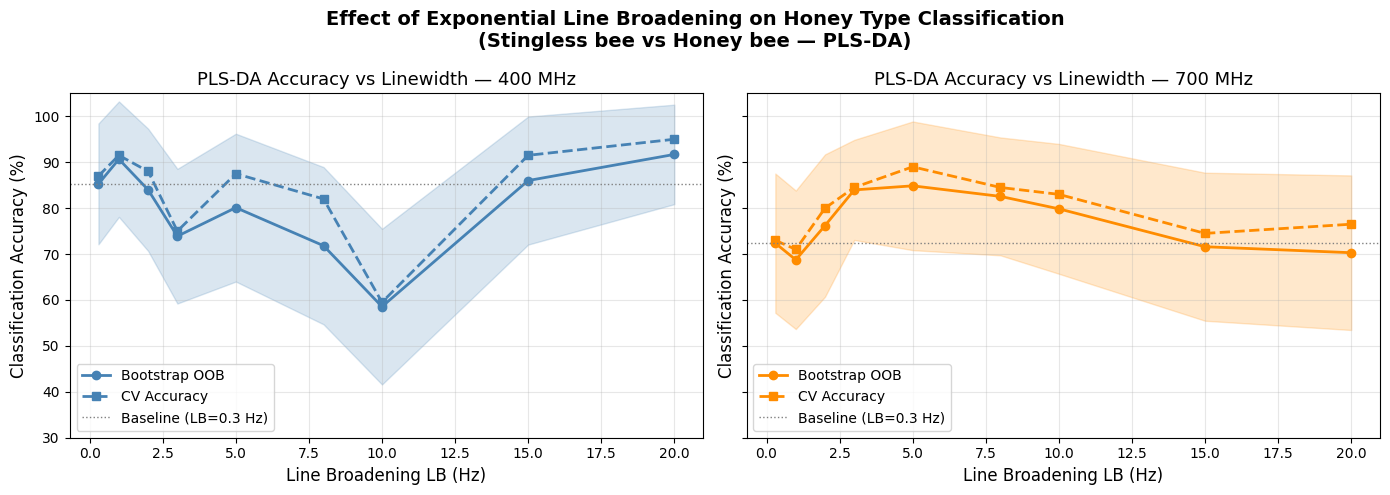

Plot saved to linewidth_vs_accuracy.png


In [51]:

# ─────────────────────────────────────────────
# 4. PLOT RESULTS
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, results, label, color in zip(
    axes,
    [results_400, results_700],
    ["400 MHz", "700 MHz"],
    ["steelblue", "darkorange"]
):
    if results.empty:
        ax.set_title(f"{label} — No results")
        continue

    ax.plot(results["LB_Hz"], results["oob_mean"] * 100,
            marker="o", color=color, linewidth=2, label="Bootstrap OOB")
    ax.fill_between(
        results["LB_Hz"],
        (results["oob_mean"] - results["oob_std"]) * 100,
        (results["oob_mean"] + results["oob_std"]) * 100,
        alpha=0.2, color=color
    )
    ax.plot(results["LB_Hz"], results["cv_mean"] * 100,
            marker="s", color=color, linewidth=2,
            linestyle="--", label="CV Accuracy")

    # Reference line at original accuracy
    orig = results[results["LB_Hz"] == 0.3]
    if not orig.empty:
        ax.axhline(orig["oob_mean"].values[0] * 100,
                   color="gray", linestyle=":", linewidth=1,
                   label="Baseline (LB=0.3 Hz)")

    ax.set_xlabel("Line Broadening LB (Hz)", fontsize=12)
    ax.set_ylabel("Classification Accuracy (%)", fontsize=12)
    ax.set_title(f"PLS-DA Accuracy vs Linewidth — {label}", fontsize=13)
    ax.legend(fontsize=10)
    ax.set_ylim(30, 105)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Effect of Exponential Line Broadening on Honey Type Classification\n"
    "(Stingless bee vs Honey bee — PLS-DA)",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("linewidth_vs_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to linewidth_vs_accuracy.png")


In [52]:

# ─────────────────────────────────────────────
# 5. SUMMARY TABLE
# ─────────────────────────────────────────────

print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(f"\n{'LB (Hz)':<10} {'400 MHz OOB':<20} {'700 MHz OOB':<20}")
print("-"*50)

for lb in LB_VALUES:
    r4 = results_400[results_400["LB_Hz"] == lb]
    r7 = results_700[results_700["LB_Hz"] == lb]
    acc4 = f"{r4['oob_mean'].values[0]*100:.1f}% ± {r4['oob_std'].values[0]*100:.1f}%" if not r4.empty else "N/A"
    acc7 = f"{r7['oob_mean'].values[0]*100:.1f}% ± {r7['oob_std'].values[0]*100:.1f}%" if not r7.empty else "N/A"
    print(f"{lb:<10} {acc4:<20} {acc7:<20}")

print("\nDone. Check linewidth_vs_accuracy.png and CSV files for full results.")


SUMMARY TABLE

LB (Hz)    400 MHz OOB          700 MHz OOB         
--------------------------------------------------
0.3        85.3% ± 13.1%        72.4% ± 15.2%       
1.0        90.7% ± 12.6%        68.7% ± 15.1%       
2.0        84.0% ± 13.3%        76.2% ± 15.5%       
3.0        73.9% ± 14.7%        84.0% ± 10.9%       
5.0        80.1% ± 16.1%        84.9% ± 14.0%       
8.0        71.8% ± 17.1%        82.6% ± 12.8%       
10.0       58.5% ± 16.9%        79.8% ± 14.1%       
15.0       86.0% ± 13.9%        71.6% ± 16.1%       
20.0       91.7% ± 10.8%        70.3% ± 16.8%       

Done. Check linewidth_vs_accuracy.png and CSV files for full results.
